# **CS 559-WS1: Machine Learning: Fundamentals and Applications**
# **Homework 3**

**Name: Ankit Dhandharia**

**CWID: 20033031**

In [2]:
# Import required libraries
import numpy as np

# **Question 1: Neural Networks**

## **Part a: Implement forward propagation as a function**

In [1]:
# x: inputs
# y: outputs
# ws: weights
# bs: biases
# zs: the z values
# E: the total error
def forward_prop(x, y, ws, bs):
    zs = [x]  # First z is the input
    def sigmoid(z):
        return 1 / (1 + np.exp(-z))
    for i in range(len(ws)):
        z = np.dot(ws[i], zs[-1]) + bs[i]
        a = sigmoid(z) # Apply activation function
        zs.append(a) # Store the activation

    output = zs[-1]
    E = 0.5 * np.sum((y - output) ** 2) # Calculate error
    return zs, E

In [3]:
x = np.array([0.7, 0.3, 0.5]).reshape(3, 1)
y = np.array([1]).reshape(1, 1)
weights = [np.array([[-1.0, -2.3, 1.7],
                    [-0.8, 0.3, 1.4]]), np.array([[-2.0, -0.4]])]
biases = [np.array([[1.6], [-0.6]]), np.array([[-0.5]])]

zs, E = forward_prop(x, y, weights, biases)

print(f'zs = {zs}')
print(f'E = {E}')

zs = [array([[0.7],
       [0.3],
       [0.5]]), array([[0.74269055],
       [0.40854102]]), array([[0.10444365]])]
E = 0.4010105918229552


## **Part b: Implement back propagation as a function**

In [4]:
def back_prop(y, zs, ws, bs, eta):
    L = len(zs) - 1
    new_ws = [w.copy() for w in ws]
    new_bs = [b.copy() for b in bs]

    def sigmoid_derivative(z): # Sigmoid derivative
        return z * (1 - z)

    delta = -(y - zs[L]) * sigmoid_derivative(zs[L]) # Initialize delta for output layer

    # Backpropagate through each layer
    for l in range(L, 0, -1):
        new_ws[l-1] = new_ws[l-1] - eta * np.dot(delta, zs[l-1].T) # Update weights
        new_bs[l-1] = new_bs[l-1] - eta * delta # Update biases
        if l > 1:
            delta = np.dot(ws[l-1].T, delta) * sigmoid_derivative(zs[l-1])

    return new_ws, new_bs

In [5]:
eta = 3.0

weights, biases = back_prop(y, zs, weights, biases, eta)

print(f'weights = {weights}')
print(f'biases = {biases}')

weights = [array([[-1.06723274, -2.32881403,  1.65197662],
       [-0.81700229,  0.2927133 ,  1.38785551]]), array([[-1.81336331, -0.29733444]])]
biases = [array([[ 1.50395323],
       [-0.62428899]]), array([[-0.24870195]])]


## **Part c: Run your code on the following example**

In [6]:
x = np.array([5.2, -2.3, -1.7, 8.3]).reshape(4, 1)
y = np.array([0, 1]).reshape(2, 1)
eta = 5.0
weights = [np.array([
    [0.09, -0.68, -0.38, 0.93],
    [-0.37, 0.61, 0.45, 0.57],
    [-0.29, -0.76, 0.46, 0.01]]),
    np.array([[0.20, -0.20, 0.83],
            [0.35, -0.59, 0.36]])]
biases = [np.array([[-0.53], [0.84], [-0.34]]), np.array([[-0.31], [0.36]])]

zs, E = forward_prop(x, y, weights, biases)
print(f'zs = {zs}')
print(f'E = {E}')

weights, biases = back_prop(y, zs, weights, biases, eta)
print(f'weights = {weights}')
print(f'biases = {biases}')

zs = [array([[ 5.2],
       [-2.3],
       [-1.7],
       [ 8.3]]), array([[0.99994814],
       [0.81442149],
       [0.31023947]]), array([[0.4961511 ],
       [0.58447212]])]
E = 0.2094146646690716
weights = [array([[ 0.09001418, -0.68000627, -0.38000463,  0.93002263],
       [-0.50649493,  0.67037276,  0.49462334,  0.35213309],
       [-0.660631  , -0.59606706,  0.58116783, -0.5815841 ]]), array([[-0.42011997, -0.70506522,  0.63760433],
       [ 0.8545586 , -0.17905532,  0.51654211]])]
biases = [array([[-0.52999727],
       [ 0.81375097],
       [-0.41127519]]), array([[-0.93015212],
       [ 0.86458477]])]


# **Question 2: Training Data Process**

In [21]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

## **Load data**

In [8]:
hitters = pd.read_csv('Hitters.csv')
hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


## **Part a: Split the data into training and test sets by 8 to 2 using sklearn.model_selection**

In [9]:
X_train, X_test = train_test_split(hitters, test_size=0.2, random_state=42)

In [11]:
X_train.shape

(257, 20)

In [12]:
X_test.shape

(65, 20)

## **Part b: Perform EDA using the training data and explain the findings with visualizations**

<class 'pandas.core.frame.DataFrame'>
Index: 257 entries, 180 to 102
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      257 non-null    int64  
 1   Hits       257 non-null    int64  
 2   HmRun      257 non-null    int64  
 3   Runs       257 non-null    int64  
 4   RBI        257 non-null    int64  
 5   Walks      257 non-null    int64  
 6   Years      257 non-null    int64  
 7   CAtBat     257 non-null    int64  
 8   CHits      257 non-null    int64  
 9   CHmRun     257 non-null    int64  
 10  CRuns      257 non-null    int64  
 11  CRBI       257 non-null    int64  
 12  CWalks     257 non-null    int64  
 13  League     257 non-null    object 
 14  Division   257 non-null    object 
 15  PutOuts    257 non-null    int64  
 16  Assists    257 non-null    int64  
 17  Errors     257 non-null    int64  
 18  Salary     212 non-null    float64
 19  NewLeague  257 non-null    object 
dtypes: float64(1)

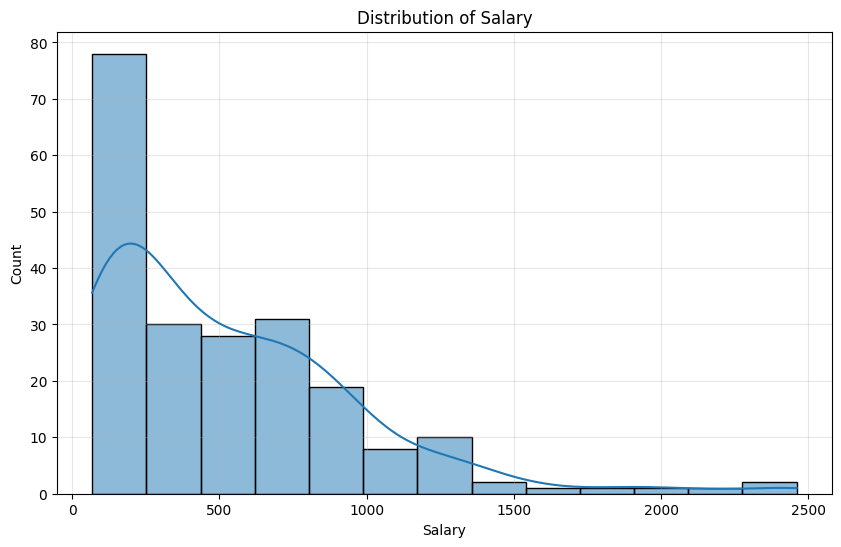

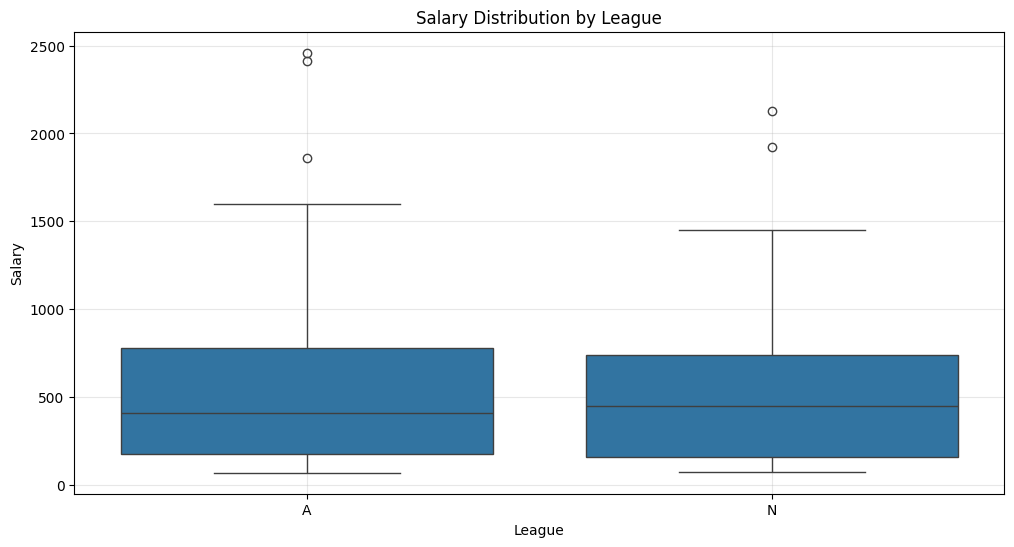

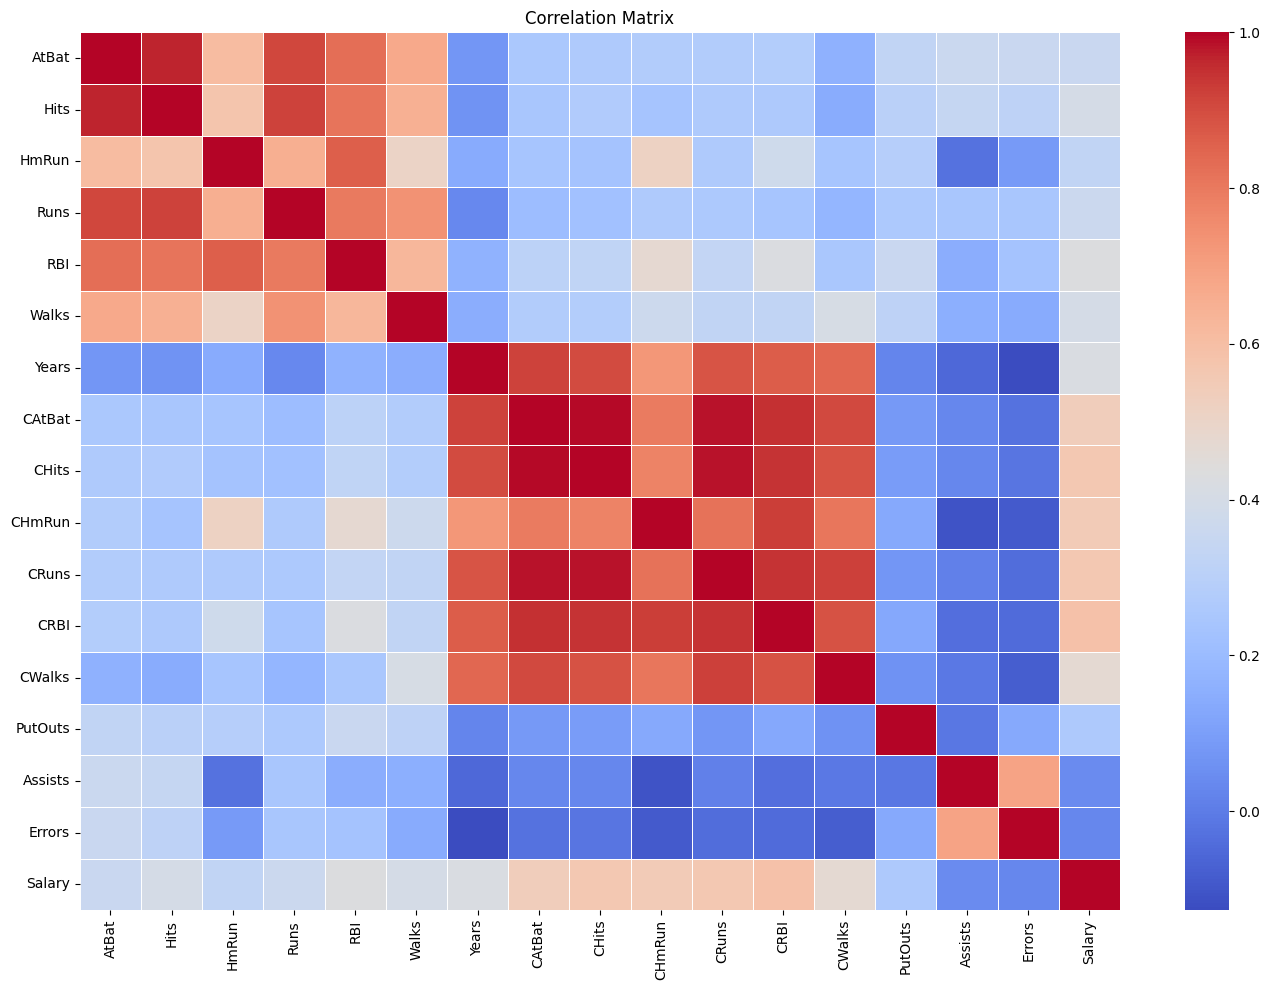

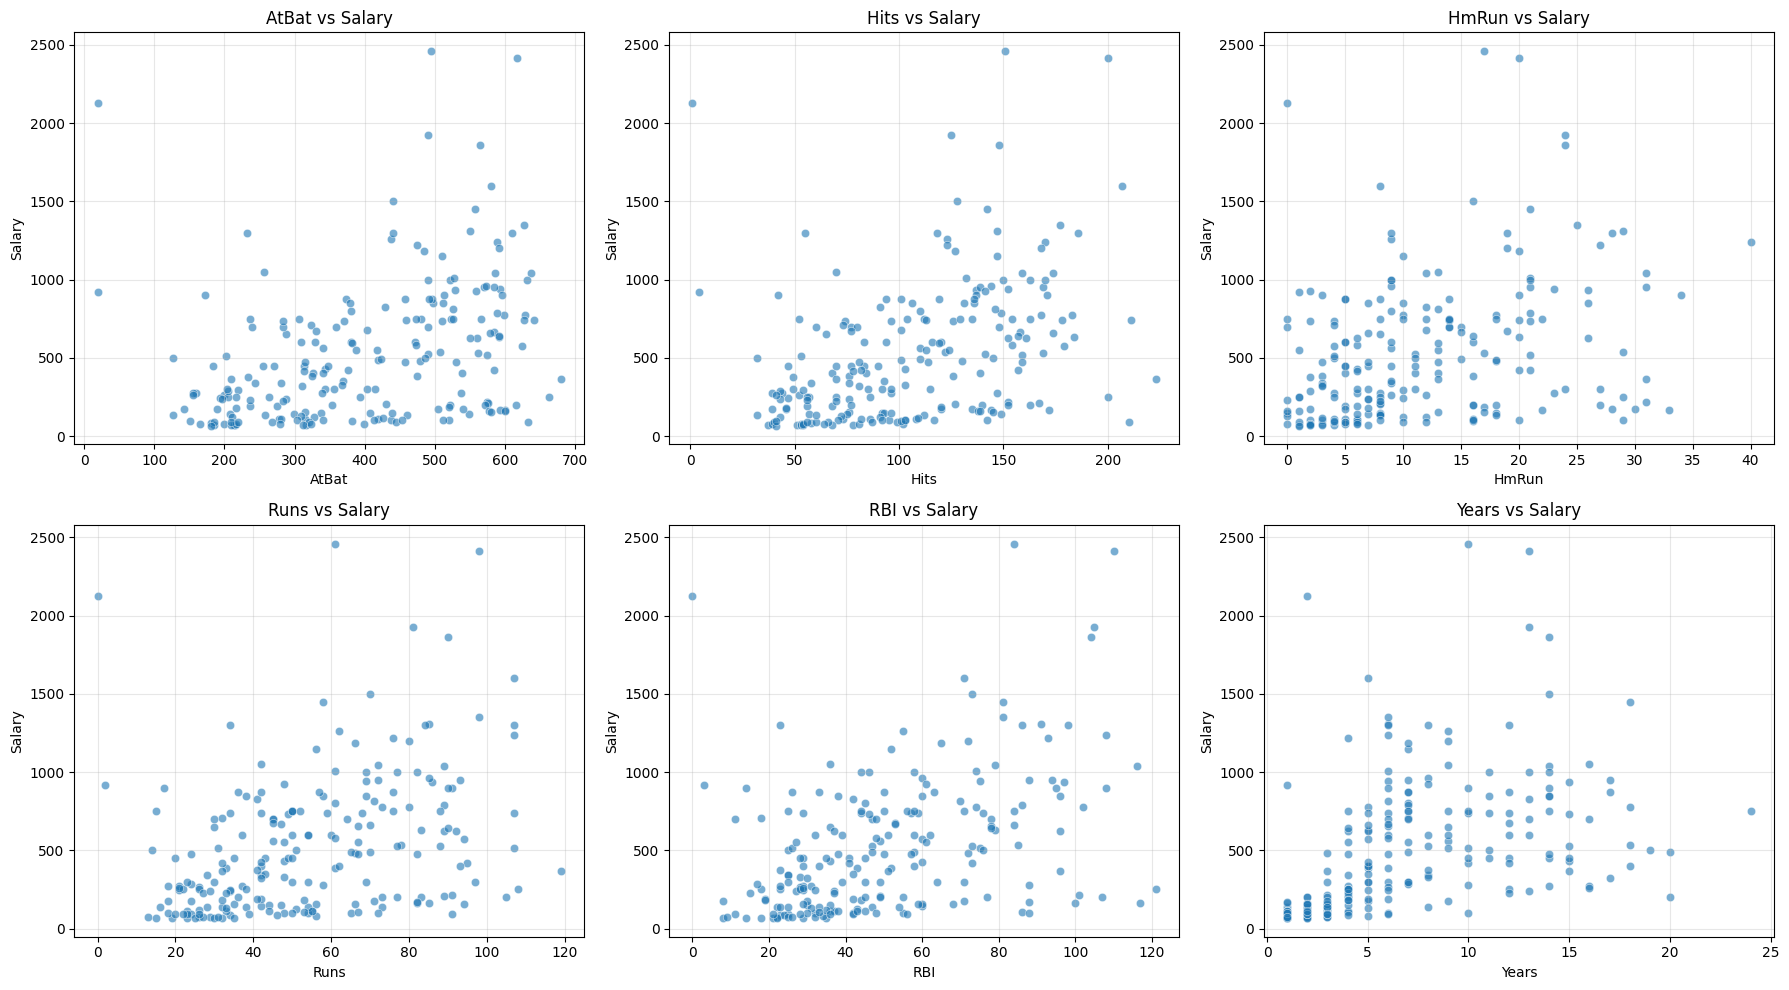

In [15]:
# Basic information about the dataset
print(X_train.info())
print("\nSummary Statistics:")
print(X_train.describe())

# Check for missing values
print("\nMissing Values:")
print(X_train.isnull().sum())

# Distribution of the target variable - Salary
plt.figure(figsize=(10, 6))
sns.histplot(X_train['Salary'].dropna(), kde=True)
plt.title('Distribution of Salary')
plt.xlabel('Salary')
plt.grid(True, alpha=0.3)
plt.show()

# Box plot of Salary by League
plt.figure(figsize=(12, 6))
sns.boxplot(x='League', y='Salary', data=X_train)
plt.title('Salary Distribution by League')
plt.grid(True, alpha=0.3)
plt.show()

# Correlation matrix
plt.figure(figsize=(14, 10))
corr_matrix = X_train.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Scatter plots of key features vs Salary
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

features = ['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Years']
for i, feature in enumerate(features):
    sns.scatterplot(x=feature, y='Salary', data=X_train, ax=axes[i], alpha=0.6)
    axes[i].set_title(f'{feature} vs Salary')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **Findings**

 **Scatter Plots**

 - AtBat vs Salary: Positive trend with high variance
 - Hits vs Salary: Similar positive relationship  
 - HmRun vs Salary: Some correlation, players clustered at lower values
 - Runs vs Salary: Positive trend with scattered high earners
 - RBI vs Salary: Shows positive relationship
 - Years vs Salary: Clear positive relationship, experienced players earn more

**Salary Distribution**

 - Most players earn below \$500
 - Few players earn above \$1,500

**Salary by League**

 - No significant difference between leagues A and N
 - Similar median values
 - Similar interquartile ranges
 - Both leagues have high-salary outliers

**Correlation Matrix**

 - Strong correlation between related offensive metrics (red blocks)
 - Career stats (CAtBat, CHits, ...) correlate strongly with Years
 - Moderate correlation between some career stats and Salary



## **Part c: Perform feature extraction, engineering, and selection using the training data**

In [16]:
X_train_clean = X_train.copy()

median_salary = X_train_clean['Salary'].median()
X_train_clean['Salary'] = X_train_clean['Salary'].fillna(median_salary)
X_train_encoded = pd.get_dummies(X_train_clean, columns=['League', 'Division', 'NewLeague'], drop_first=True)

# Feature engineering
# Batting average = Hits / AtBat
X_train_encoded['BattingAvg'] = X_train_encoded['Hits'] / X_train_encoded['AtBat']
# Replace infinities with 0 andNaN with 0
X_train_encoded['BattingAvg'] = X_train_encoded['BattingAvg'].replace([np.inf, -np.inf], 0)
X_train_encoded['BattingAvg'] = X_train_encoded['BattingAvg'].fillna(0)

# Home run rate = HmRun / AtBat
X_train_encoded['HmRunRate'] = X_train_encoded['HmRun'] / X_train_encoded['AtBat']
X_train_encoded['HmRunRate'] = X_train_encoded['HmRunRate'].replace([np.inf, -np.inf], 0)
X_train_encoded['HmRunRate'] = X_train_encoded['HmRunRate'].fillna(0)

# On-base percentage (simple version): (Hits + Walks) / AtBat
X_train_encoded['OnBasePercent'] = (X_train_encoded['Hits'] + X_train_encoded['Walks']) / X_train_encoded['AtBat']
X_train_encoded['OnBasePercent'] = X_train_encoded['OnBasePercent'].replace([np.inf, -np.inf], 0)
X_train_encoded['OnBasePercent'] = X_train_encoded['OnBasePercent'].fillna(0)

# Fielding percentage: (PutOuts + Assists) / (PutOuts + Assists + Errors)
X_train_encoded['FieldingPercent'] = (X_train_encoded['PutOuts'] + X_train_encoded['Assists']) / (X_train_encoded['PutOuts'] + X_train_encoded['Assists'] + X_train_encoded['Errors'])
X_train_encoded['FieldingPercent'] = X_train_encoded['FieldingPercent'].replace([np.inf, -np.inf], 0)
X_train_encoded['FieldingPercent'] = X_train_encoded['FieldingPercent'].fillna(0)

# Feature selection based on correlation with Salary
plt.figure(figsize=(12, 8))
correlation_with_salary = X_train_encoded.corr()['Salary'].sort_values(ascending=False)
print("Correlation with Salary:")
print(correlation_with_salary)

# Select top features based on correlation (absolute value)
correlation_threshold = 0.3
selected_features = correlation_with_salary[abs(correlation_with_salary) > correlation_threshold].index.tolist()
selected_features.remove('Salary')  # Remove the target variable

print("Selected Features:")
print(selected_features)

# Create a new dataframe with only the selected features
X_train_selected = X_train_encoded[selected_features + ['Salary']]
print("Final Training Dataset Shape:")
print(X_train_selected.shape)

Correlation with Salary:
Salary             1.000000
CRBI               0.537453
CHits              0.515594
CRuns              0.515033
CHmRun             0.488559
CAtBat             0.488214
CWalks             0.422852
RBI                0.410479
Walks              0.381288
Hits               0.380737
Years              0.375017
Runs               0.352584
AtBat              0.338965
HmRun              0.315847
PutOuts            0.231511
OnBasePercent      0.170516
HmRunRate          0.141019
BattingAvg         0.140414
Assists            0.053568
Errors             0.040383
FieldingPercent    0.021476
League_N          -0.018237
NewLeague_N       -0.032595
Division_W        -0.150591
Name: Salary, dtype: float64

Selected Features:
['CRBI', 'CHits', 'CRuns', 'CHmRun', 'CAtBat', 'CWalks', 'RBI', 'Walks', 'Hits', 'Years', 'Runs', 'AtBat', 'HmRun']

Final Training Dataset Shape:
(257, 14)


<Figure size 1200x800 with 0 Axes>

## **Part d: Perform feature extraction, engineering, and selection using the testing data**